### Data Loading and EDA

The Dataset here is a Telecom Customer Dataset that can be used for to predict the churn analysis. Here we are going to use EDA to answer Questions and visualize them. This will help find interesting insights and stories about customers.

In [1]:
# Loading the python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# load the dataset                                                                                                  
data = pd.read_csv('../data/raw/churn_data.csv')
# check the first 5 rows of the dataset
data.head()

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


### About Dataset

This dataset is a Telecom customer churn dataset designed to analyze customer behavior and predict whether a customer is likely to stop using a service. Churn prediction is critical because losing customers directly impacts revenue and business growth.

 - Age    - Age of the customers
 - Gender - Gender of Customer
 - Tenure - No of Months the customers are with service
 - Usage Frequency - Months they were used
 - Support Calls - The number of times the customer has contacted customer service for assistance or technical issues.
 - Payment Delay - The average or total number of days a customer’s payment was overdue. High delays often correlate with churn.
 - Subscription Type - The specific tier or plan the customer is enrolled in (Basic, Standard, Premium).
 - Contract Length - The duration of the service agreement. Shorter contracts (Monthly) typically have higher churn than Yearly ones.
 - Total Spend - The cumulative amount of money the customer has spent since joining the service.
 - Last Interaction - Time elapsed since the customer last engaged with the service or app (e.g., logged in or used data).
 - Churn - The target variable indicating if the customer left (1) or stayed (0).

First before analysis let's clean the Data frame before proceeding with any Analysis.

In [3]:
# Dropping 'Unnamed: 0'
data.drop('Unnamed: 0', axis=1, inplace=True)
data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
# since CustomerID is not useful for our analysis, we will make it as index column
data.set_index('CustomerID', inplace=True)
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
CustomerID,,,,,,,,,,,
2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


Now Let's check for missing values available in Data and remove them after investigating.

In [5]:
print(f'There are {data.shape[0]} rows and {data.shape[1]} columns in the dataset.')

There are 440833 rows and 11 columns in the dataset.


In [6]:
# Let's check Data.info() to see the data types and missing values
data.info()

<class 'pandas.DataFrame'>
Index: 440833 entries, 2.0 to 449999.0
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  str    
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  str    
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), str(3)
memory usage: 48.5 MB


There is one value is here is missing from each column, we have to check whether it is in one row or multiple rows

In [7]:
# Triangulating the missing values
data[data.isnull().any(axis=1)]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
CustomerID,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


since one row has all missing values let's remove it from sample

In [8]:
data = data[~data.isnull().any(axis=1)]
df = data.copy()

In [9]:
# double checking if there are any missing values left
data.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [10]:
# check the shape of the dataset
data.shape

(440832, 11)

In [11]:
# Let's use describe() to get the summary statistics of the numerical columns & categorical columns
data.describe(include='all')

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832,440832.000000,440832.000000,440832.000000,440832.000000,440832,440832,440832.000000,440832.000000,440832.000000
unique,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,250252,NaN,NaN,NaN,NaN,149128,177198,NaN,NaN,NaN
mean,39.373153,NaN,31.256336,15.807494,3.604437,12.965722,NaN,NaN,631.616223,14.480868,0.567107
std,12.442369,NaN,17.255727,8.586242,3.070218,8.258063,NaN,NaN,240.803001,8.596208,0.495477
min,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,29.000000,NaN,16.000000,9.000000,1.000000,6.000000,NaN,NaN,480.000000,7.000000,0.000000
50%,39.000000,NaN,32.000000,16.000000,3.000000,12.000000,NaN,NaN,661.000000,14.000000,1.000000
75%,48.000000,NaN,46.000000,23.000000,6.000000,19.000000,NaN,NaN,830.000000,22.000000,1.000000


### Variables Distributions
Before proceeding with EDA let't check each variables features

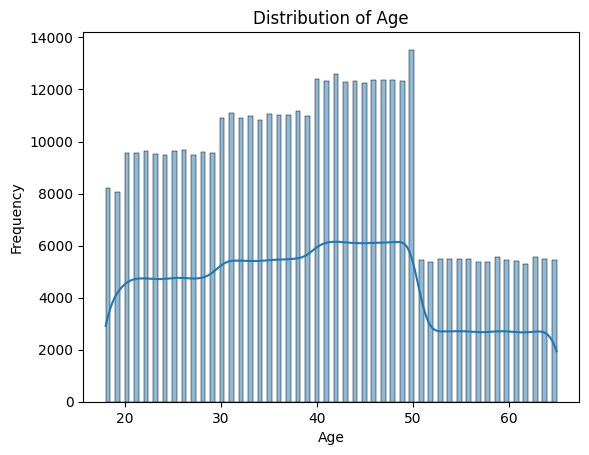

Gender: 2 unique values


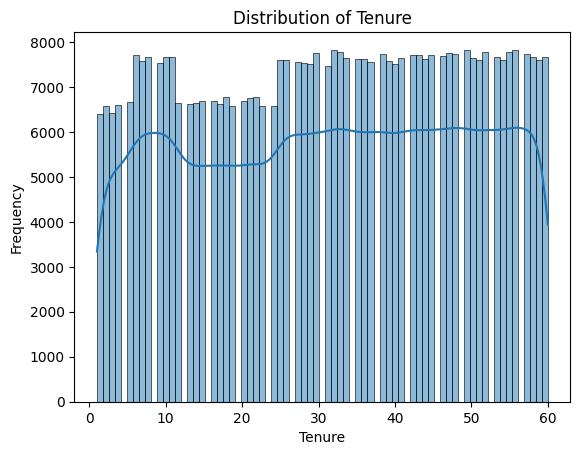

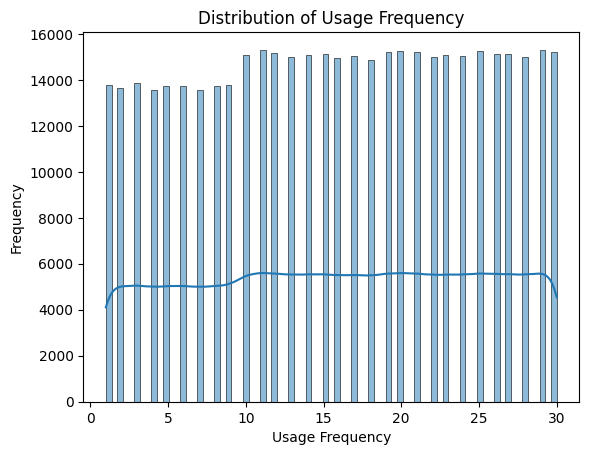

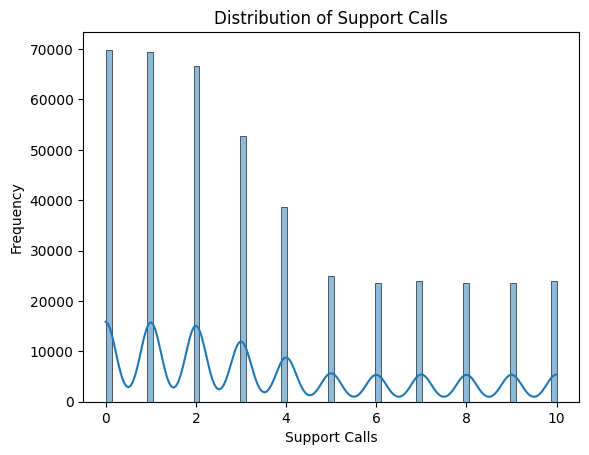

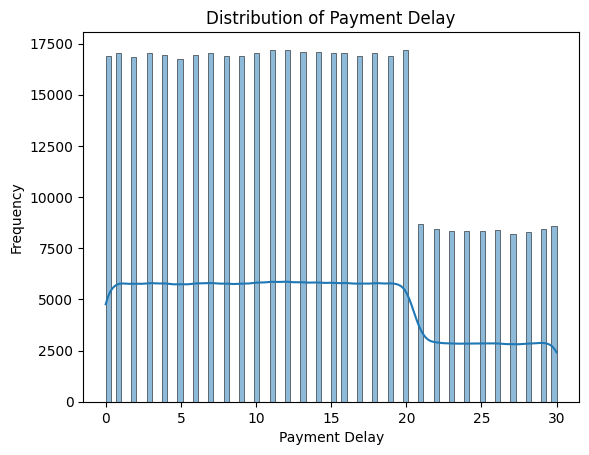

Subscription Type: 3 unique values
Contract Length: 3 unique values


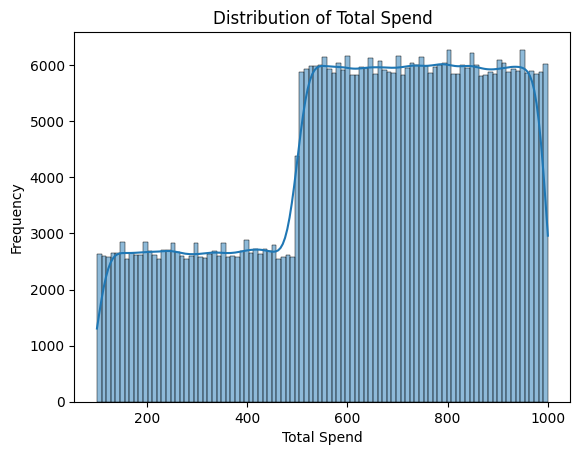

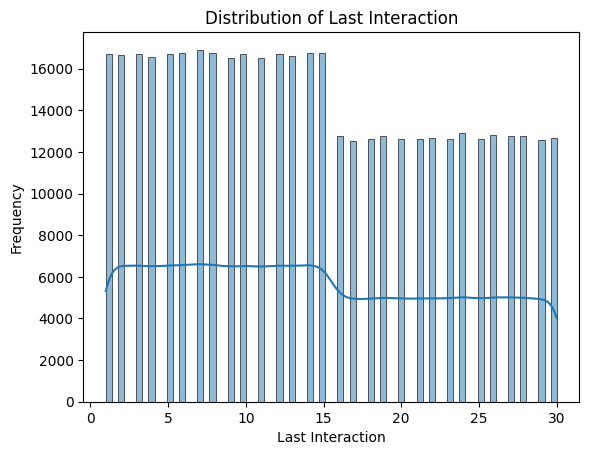

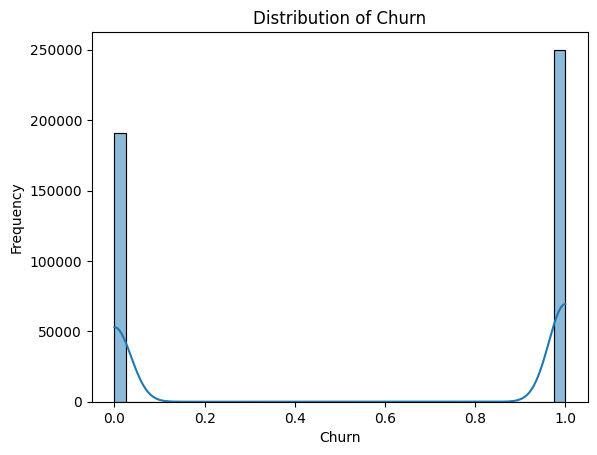

In [12]:
for col in data.columns:
    if data[col].dtype == 'str':
        print(f"{col}: {data[col].nunique()} unique values")
    elif data[col].dtype in ['int64', 'float64']:
        sns.histplot(data[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

Now let see how each numeric values are correlated

In [13]:
cols = []
for col in data.columns:
    if data[col].dtype in ['int64', 'float64']:
        cols.append(col)

data[cols].corr()


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


In [14]:
data["Churn_status"] = data["Churn"].apply(lambda x: "Churned" if x == 1 else "Not Churned")



- The **strongest driver of churn** is **customer support activity**, indicating dissatisfaction or unresolved issues.
- **Financial behavior** — specifically **payment delay** and **total spend** — plays a significant role in churn.
- **Demographic (Age)** and **engagement features (Usage, Tenure)** have weaker influence on churn.


The dataset suggests that churn is primarily driven by:

- **Customer Experience Issues**
  - High number of support calls indicates dissatisfaction

- **Financial Behavior**
  - Delayed payments reflect potential risk or disengagement
  - Lower total spend indicates lower perceived value

- **Perceived Value**
  - Customers who spend more tend to stay longer
  - Lower-value customers are more likely to churn


> Customers are more likely to churn when they experience poor service and exhibit risky financial behavior, rather than due to demographic or basic usage patterns.

### **Analysis**

Now Let's Answer Questions following Questions

#### **🎯 Customer Behavior & Lifecycle**
1. How do new customers differ from long-term customers in terms of usage and spending?
2. At what tenure stage do customers become more active or valuable?
3. Do long-term customers consistently generate higher revenue?
4. Is there a point where customer engagement starts to decline?

In [15]:
# How do New Customers differ from Existing Customers in terms of their usage and spending?
# To answer this Question, we have to create a column call new vs existing customers. We can use the tenure column to create this column. If the tenure is less than or equal to 12 months, we can consider them as new customers, otherwise, they are existing customers.

data['Customer_Type'] = data['Tenure'].apply(lambda x: 'New Customer' if x <= 12 else 'Existing Customer')
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Churn_status,Customer_Type
CustomerID,,,,,,,,,,,,,
2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Churned,Existing Customer
3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Churned,Existing Customer
4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Churned,Existing Customer
5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Churned,Existing Customer
6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Churned,Existing Customer


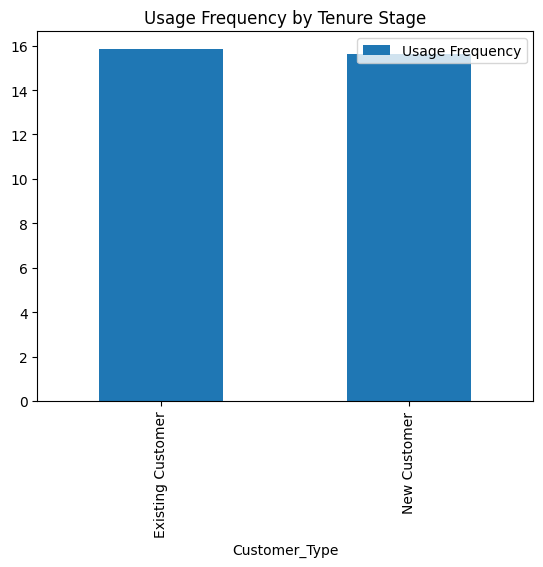

In [16]:
usage_by_type = data.groupby('Customer_Type')[["Usage Frequency"]].mean()
usage_by_type.plot(kind="bar")
plt.title("Usage Frequency by Tenure Stage")
plt.show()

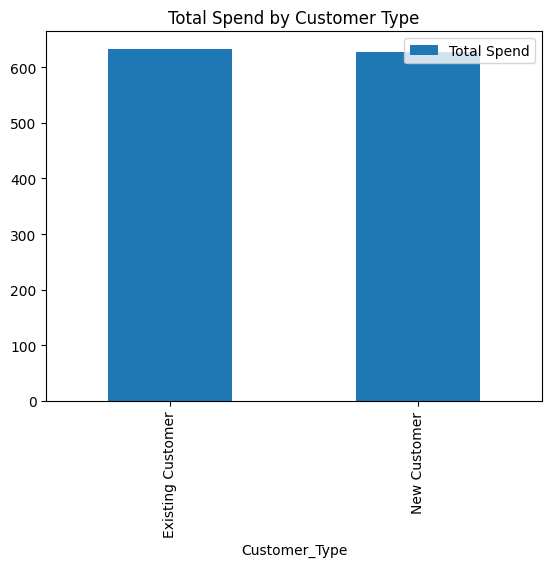

In [17]:
usage_by_type = data.groupby('Customer_Type')[["Total Spend"]].mean()
usage_by_type.plot(kind="bar")
plt.title("Total Spend by Customer Type")
plt.show()

The comparison between new and existing customers shows negligible differences in both usage frequency and total spend. This indicates that tenure does not significantly influence customer behavior in this dataset.

Therefore, tenure-based segmentation is not effective, and the analysis should instead focus on behavior-driven features such as support calls, payment delay, and total spend.

In [18]:
# At what tenure stage do customers become more active or valuable?

# To answer this question, we can create a new column called 'Tenure Stage' based on the tenure column. We can categorize the tenure into different stages such as '0-6 months', '7-12 months', '13-24 months', and '25+ months'.

data["Tenure_Stage"] = pd.cut(data["Tenure"], bins=[0, 6, 12, 24, np.inf], labels=['0-6 months', '7-12 months', '13-24 months', '25+ months'])
data.head()


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Churn_status,Customer_Type,Tenure_Stage
CustomerID,,,,,,,,,,,,,,
2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Churned,Existing Customer,25+ months
3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Churned,Existing Customer,25+ months
4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Churned,Existing Customer,13-24 months
5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Churned,Existing Customer,25+ months
6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Churned,Existing Customer,25+ months


In [19]:
data["Tenure_Stage"].value_counts()

Tenure_Stage
25+ months      275736
13-24 months     79967
7-12 months      44751
0-6 months       40378
Name: count, dtype: int64

Based on tenure stage we can see we have most of customers bases are Tenured customers since almost 70% of customers are tenured customers.

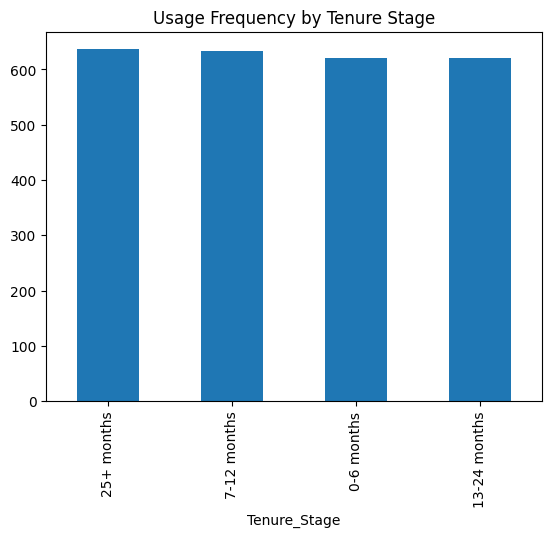

In [20]:
# Let's check when they become more valuable customers by looking at average total spend by tenure stage

usage_by_tenure = data.groupby('Tenure_Stage')["Total Spend"].mean().sort_values(ascending=False)
usage_by_tenure.plot(kind="bar")
plt.title("Usage Frequency by Tenure Stage")
plt.show()

Analysis of total spend across tenure stages shows minimal variation, with average spend remaining relatively consistent across all groups. This indicates that tenure does not significantly influence customer spending behavior.

Therefore, tenure does not provide meaningful separation for clustering and was excluded from segmentation features.

In [21]:
# Do long-term customers consistently generate higher revenue?
# To answer this question, we can analyze the average total spend by tenure stage. We can also visualize this relationship using a bar plot to see if there is a consistent increase in revenue as customers stay longer with the company.

data.groupby('Tenure_Stage')["Total Spend"].mean()

Tenure_Stage
0-6 months      621.151043
7-12 months     633.143997
13-24 months    619.847030
25+ months      636.313980
Name: Total Spend, dtype: float64

There is no significant different between Short Tenure (0-12 months) & Long Tenure (13-25 or More) are almost same. On Segmentation we can surely remove Tenure column.

In [22]:
# Is there a point where customer engagement starts to decline?
# To answer this question, we can analyze the average usage frequency by tenure stage. We can also visualize this relationship using a bar plot to see if there is a point where customer engagement starts to decline as customers stay longer with the company.
data.groupby('Tenure_Stage')["Usage Frequency"].mean()

Tenure_Stage
0-6 months      15.481970
7-12 months     15.769055
13-24 months    17.030212
25+ months      15.506796
Name: Usage Frequency, dtype: float64

Here we can see the Time is not a good feature to us for Segmentation.

#### 💰 Value & Revenue Insights
- What defines a high-value customer in this dataset & ?
- What behaviors are common among high-value customers?
- Are high-usage customers always high-value customers?
- Which combination of features (tenure, usage, plan) drives the most revenue?

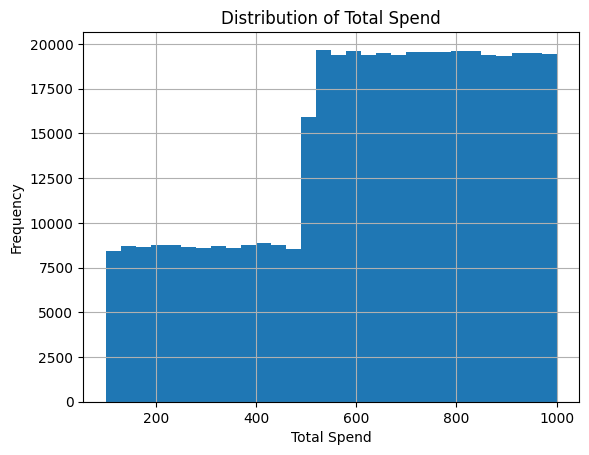

In [23]:
# Let's check distribution of Total spend
data["Total Spend"].hist(bins=30)
plt.title("Distribution of Total Spend")
plt.xlabel("Total Spend")
plt.ylabel("Frequency")
plt.show()

Here we can see a there is sharp increase in spend from $500, therefore we should consider any value above $500 is considered High value customers.

In [24]:
data["Total Spend"].describe()

count    440832.000000
mean        631.616223
std         240.803001
min         100.000000
25%         480.000000
50%         661.000000
75%         830.000000
max        1000.000000
Name: Total Spend, dtype: float64

In [25]:
data["Total Spend"].quantile(0.75)

np.float64(830.0)

In [26]:
# Let's create a new column called 'Customer Type' based on the total spend. We can categorize the customers into 'high spender' and 'low spender' based on a threshold of 830.0. If the total spend is greater than 50830.00, we can consider them as high spenders, otherwise, they are low spenders.
data["Customer_Type"] = data["Total Spend"].apply(lambda x : 'high spender' if x > 830.0 else 'low spender')

In [27]:
data["Customer_Type"].value_counts()

Customer_Type
low spender     330706
high spender    110126
Name: count, dtype: int64

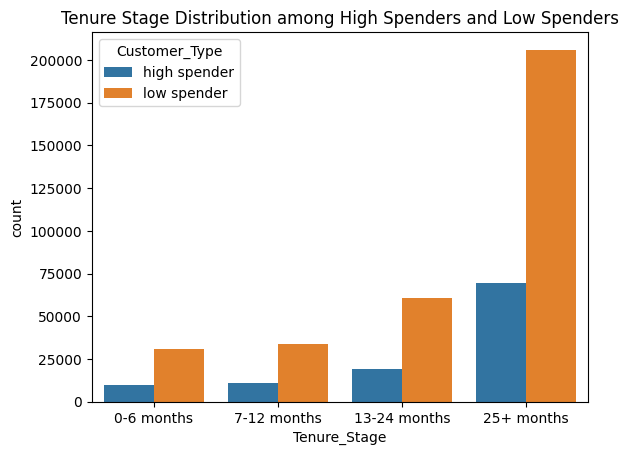

In [28]:
# Let's see how tenure stage is distributed among high spenders and low spenders
sns.countplot(x="Tenure_Stage", hue="Customer_Type", data=data)
plt.title("Tenure Stage Distribution among High Spenders and Low Spenders")
plt.show()

Here we can see that the High value customer are long term Customers, we can see 13-25 + customers are spending more on product

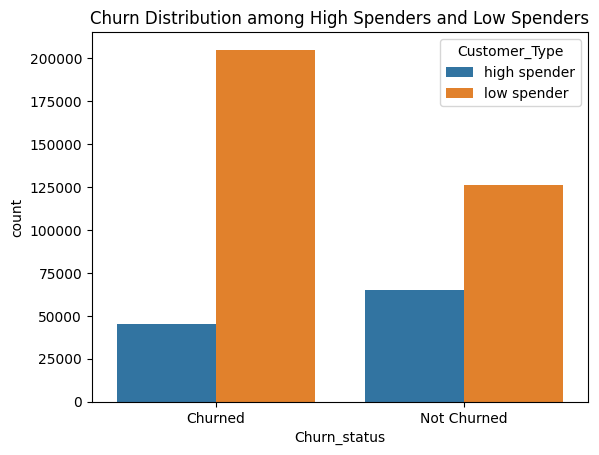

In [29]:
# Let's see how many of high spenders and low spenders have churned
sns.countplot(x="Churn_status", hue="Customer_Type", data=data)
plt.title("Churn Distribution among High Spenders and Low Spenders")
plt.show()

The analysis shows that high-spending customers have a lower churn rate compared to low-spending customers. This indicates that customers who generate higher revenue are more likely to remain with the service.

This behavior may be associated with higher perceived value, stronger engagement, or better overall experience among high-value customers.

High-value customers are defined not only by their spending but also by their overall contribution to business profitability. 

A truly high-value customer:
- Generates high revenue (high total spend)
- Uses the service actively (high usage frequency)
- Requires minimal support (low support calls)
- Demonstrates reliable financial behavior (low payment delay)

Customers who incur high service costs or exhibit risky payment behavior may reduce overall profitability, even if their spending is high.

In [30]:
# What defines a high-value customer in this dataset?
# Calculate thresholds once
spend_threshold = data["Total Spend"].quantile(0.75)
usage_threshold = data["Usage Frequency"].median()
support_threshold = data["Support Calls"].median()
delay_threshold = data["Payment Delay"].median()


data["Spending"] = data["Total Spend"].apply(lambda x: 1 if x > spend_threshold else 0)
# For usage Frequency we are going check whether they are higher than median or not
data["Usage"] = data["Usage Frequency"].apply(lambda x: 1 if x > usage_threshold else 0)
# For Support Tickets we are going to check whether they are Less than median or not
data["Support"] = data["Support Calls"].apply(lambda x: 1 if x < support_threshold else 0)
# Same for Payment Delay
data["Delay"] = data["Payment Delay"].apply(lambda x: 1 if x < delay_threshold else 0)

data["customer_rank"] = data["Spending"] + data["Usage"] + data["Support"] + data["Delay"]
data["customer_rank"].value_counts()


customer_rank
2    148755
1    143540
3     76095
0     56973
4     15469
Name: count, dtype: int64

Here we have 5 rank segments so what we are going to do is the bucketing is going to be 0-1 Low level, 2 -3 mid value and 4 as high value customer.Here we have 5 rank segments so what we are going to do is the bucketing is going to be 0-1 Low level, 2 mid value and 3-4 as high value customer.

In [31]:
data["Customer_Value"] = data["customer_rank"].apply(lambda x: 'High Tier Customers' if x >= 3  else  ('Mid Tier Customers' if x==2  else 'Low Tier Customers'))
data["Customer_Value"].value_counts()

Customer_Value
Low Tier Customers     200513
Mid Tier Customers     148755
High Tier Customers     91564
Name: count, dtype: int64

In [32]:
#  What behaviors are common among high-value customers?
# To answer this question, we can analyze the characteristics of high-value customers by looking at their average total spend, usage frequency, support calls, and payment delay. We can also compare these characteristics with low-value customers to identify any common behaviors among high-value customers.
data.groupby("Customer_Value")[["Total Spend", "Usage Frequency", "Support Calls", "Payment Delay", 'Churn']].mean()

,Total Spend,Usage Frequency,Support Calls,Payment Delay,Churn
Customer_Value,,,,,
High Tier Customers,794.317076,20.990946,1.493294,7.272247,0.239614
Low Tier Customers,539.691835,12.364729,5.069606,17.013899,0.768519
Mid Tier Customers,655.376726,17.257538,2.928957,11.013552,0.497200


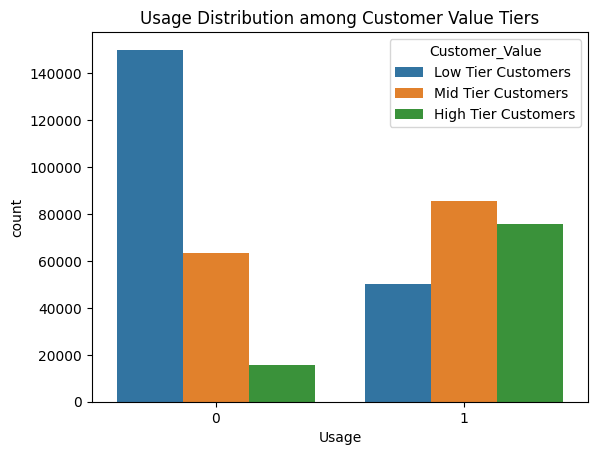

In [33]:
# Are high-usage customers always high-value customers?
# To answer this question, we can analyze the relationship between usage frequency and customer value. We can create a cross-tabulation or a bar plot to see if high-usage customers are consistently categorized as high-value customers.
sns.countplot(x="Usage", hue="Customer_Value", data=data)
plt.title("Usage Distribution among Customer Value Tiers")
plt.show()

High-value customers exhibit significantly higher engagement levels, as indicated by a larger proportion of high usage frequency. In contrast, low-value customers are predominantly characterized by low usage, suggesting that engagement is a key driver of customer value.

In [34]:
# Is there a point where customer engagement starts to decline?
# To answer this question, we can analyze the average usage frequency by tenure stage. We can also visualize this relationship using a bar plot to see if there is a point where customer engagement starts to decline as customers stay longer with the company.
data.groupby('Tenure_Stage')["Usage Frequency"].mean()

Tenure_Stage
0-6 months      15.481970
7-12 months     15.769055
13-24 months    17.030212
25+ months      15.506796
Name: Usage Frequency, dtype: float64

There is no significant decline can be see only we can see peak 13-24 month in usage and goes back to normal  15 range.

In [35]:
data.groupby(['Tenure_Stage', "Churn_status"])[["Total Spend", "Usage Frequency", "Support Calls", "Payment Delay"]].mean().reset_index()

,Tenure_Stage,Churn_status,Total Spend,Usage Frequency,Support Calls,Payment Delay
0,0-6 months,Churned,543.995877,15.466974,5.107598,15.218731
1,0-6 months,Not Churned,748.941032,15.506809,1.590422,10.050720
2,7-12 months,Churned,539.134339,15.523184,5.172783,15.254321
3,7-12 months,Not Churned,750.245650,16.075321,1.606935,10.007226
4,13-24 months,Churned,543.056862,15.310018,5.104888,15.207779
5,13-24 months,Not Churned,752.136854,19.993667,1.587164,10.036500
6,25+ months,Churned,540.586315,15.501894,5.160038,15.214850
7,25+ months,Not Churned,749.521070,15.512594,1.582527,10.007686


The Total spend can seeing a drop in total spend for users who churn, while maintaining usage frequency, we can see sharp increase average support calls & payment delay, this show if a customers reduce the spend, increase support calls & payment delay can be chance for customer to churn.

In [36]:
data["Year_of_Birth"] = 2026 - data["Age"]
data["Generations"] = pd.cut(data["Year_of_Birth"], bins=[1945, 1964, 1980, 1996, 2012], labels=[ "Baby Boomers", "Generation X", "Millennials", "Generation Z"])
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,...,Customer_Type,Tenure_Stage,Spending,Usage,Support,Delay,customer_rank,Customer_Value,Year_of_Birth,Generations
CustomerID,,,,,,,,,,,,,,,,,,,,,
2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,...,high spender,25+ months,1,0,0,0,1,Low Tier Customers,1996.0,Millennials
3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,...,low spender,25+ months,0,0,0,1,1,Low Tier Customers,1961.0,Baby Boomers
4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,...,low spender,13-24 months,0,0,0,0,0,Low Tier Customers,1971.0,Generation X
5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,...,low spender,25+ months,0,1,0,1,2,Mid Tier Customers,1968.0,Generation X
6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,...,low spender,25+ months,0,1,0,1,2,Mid Tier Customers,2003.0,Generation Z


In [37]:
data["Generations"].value_counts()

Generations
Millennials     184178
Generation X    122824
Generation Z    112026
Baby Boomers     21804
Name: count, dtype: int64

In [38]:
gen_churn_rates = data.groupby('Generations')['Churn_status'].apply(lambda x: (x == 'Churned').mean() * 100)
summary_df = gen_churn_rates.reset_index()
summary_df.columns = ['Generation', 'Churn Rate (%)']
print(summary_df.sort_values(by='Churn Rate (%)', ascending=False))

     Generation  Churn Rate (%)
0  Baby Boomers      100.000000
1  Generation X       69.041067
3  Generation Z       55.516577
2   Millennials       44.089414


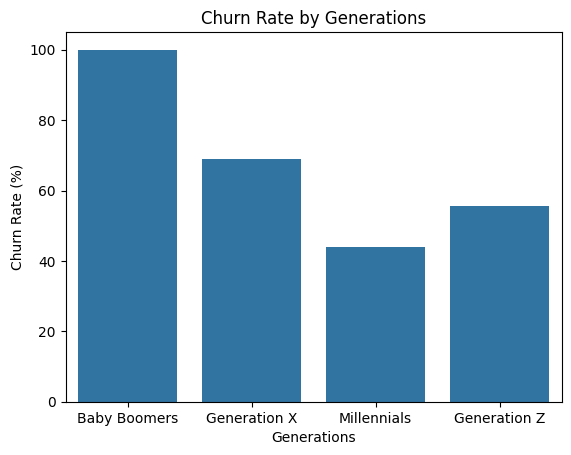

In [39]:
sns.barplot(data=summary_df, x="Generation", y="Churn Rate (%)")
plt.xlabel("Generations")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Generations")
plt.show()

In [40]:
data.groupby(['Generations', "Churn_status"])[["Total Spend", "Usage Frequency", "Support Calls", "Payment Delay"]].mean().reset_index()

,Generations,Churn_status,Total Spend,Usage Frequency,Support Calls,Payment Delay
0,Baby Boomers,Churned,550.965898,15.463906,5.038066,14.990552
1,Generation X,Churned,544.355014,15.512376,5.064458,15.143598
2,Generation X,Not Churned,750.982927,16.349086,2.098698,10.008258
3,Millennials,Churned,534.547008,15.390232,5.236272,15.336564
4,Millennials,Not Churned,749.588280,16.220083,1.711920,10.023782
5,Generation Z,Churned,542.504762,15.484974,5.172576,15.243291
6,Generation Z,Not Churned,749.921201,16.276624,0.936187,10.003913


Although churn rates vary across generations, the underlying drivers of churn are consistent across all groups.

Churned customers, regardless of generation, exhibit:
- Lower total spend
- Slightly lower usage frequency
- Significantly higher support calls
- Higher payment delays

This indicates that churn is primarily driven by customer experience and financial behavior rather than generational differences.

📊 Engagement Analysis
- What distinguishes active customers from inactive ones?
- Do customers with low engagement show early signs of reduced activity?

In [41]:
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,...,Customer_Type,Tenure_Stage,Spending,Usage,Support,Delay,customer_rank,Customer_Value,Year_of_Birth,Generations
CustomerID,,,,,,,,,,,,,,,,,,,,,
2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,...,high spender,25+ months,1,0,0,0,1,Low Tier Customers,1996.0,Millennials
3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,...,low spender,25+ months,0,0,0,1,1,Low Tier Customers,1961.0,Baby Boomers
4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,...,low spender,13-24 months,0,0,0,0,0,Low Tier Customers,1971.0,Generation X
5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,...,low spender,25+ months,0,1,0,1,2,Mid Tier Customers,1968.0,Generation X
6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,...,low spender,25+ months,0,1,0,1,2,Mid Tier Customers,2003.0,Generation Z


In [42]:
# What distinguishes active customers from inactive ones?
# Here we have taken a quantile based approach to categorize customers into 'Inactive', 'Moderate', and 'Active' based on their usage frequency. Customers with usage frequency in the lowest 25% are categorized as 'Inactive', those in the highest 25% are categorized as 'Active', and the rest are categorized as 'Moderate'.
inactive = data["Usage Frequency"].quantile(0.25)
active = data["Usage Frequency"].quantile(0.75)
data["Usage_Frequency"] = data["Usage Frequency"].apply(lambda x: 'Inactive' if x <= inactive else ('Active' if x >= active else 'Moderate'))
data["Usage_Frequency"].value_counts()

Usage_Frequency
Moderate    196368
Inactive    123334
Active      121130
Name: count, dtype: int64

In [43]:
data.groupby("Usage_Frequency")[["Total Spend", "Support Calls", "Payment Delay","Last Interaction", "Churn"]].mean().reset_index()

,Usage_Frequency,Total Spend,Support Calls,Payment Delay,Last Interaction,Churn
0,Active,634.972916,3.555973,12.876637,14.471865,0.549443
1,Inactive,622.785006,3.750782,13.198048,14.570248,0.613675
2,Moderate,635.092313,3.542415,12.874756,14.430284,0.548755


In [44]:
# What distinguishes active customers from inactive ones?
# Here we have taken a quantile based approach to categorize customers into 'Inactive', 'Moderate', and 'Active' based on their last interaction. Customers with last interaction in the lowest 25% are categorized as 'Inactive', those in the highest 25% are categorized as 'Active', and the rest are categorized as 'Moderate'.
inactive = data["Last Interaction"].quantile(0.25)
active = data["Last Interaction"].quantile(0.75)
data["Last_Interaction"] = data["Last Interaction"].apply(lambda x: 'Inactive' if x <= inactive else ('Active' if x >= active else 'Moderate'))
data["Last_Interaction"].value_counts()

Last_Interaction
Moderate    209376
Inactive    117041
Active      114415
Name: count, dtype: int64

In [45]:
data.groupby("Last_Interaction")[["Total Spend", "Support Calls", "Payment Delay","Usage Frequency", "Churn"]].mean().reset_index()

,Last_Interaction,Total Spend,Support Calls,Payment Delay,Usage Frequency,Churn
0,Active,613.272136,3.925342,13.452100,15.745252,0.665734
1,Inactive,644.725931,3.365111,12.601516,15.839432,0.492289
2,Moderate,634.312164,3.562858,12.903528,15.823652,0.555035


In [46]:
data.groupby("Last_Interaction")[["Total Spend", "Support Calls", "Payment Delay","Usage Frequency", "Churn"]].mean().reset_index()

,Last_Interaction,Total Spend,Support Calls,Payment Delay,Usage Frequency,Churn
0,Active,613.272136,3.925342,13.452100,15.745252,0.665734
1,Inactive,644.725931,3.365111,12.601516,15.839432,0.492289
2,Moderate,634.312164,3.562858,12.903528,15.823652,0.555035


In [47]:
data.groupby(["Last_Interaction", "Churn_status"])[["Total Spend", "Support Calls", "Payment Delay","Usage Frequency"]].mean().reset_index()

,Last_Interaction,Churn_status,Total Spend,Support Calls,Payment Delay,Usage Frequency
0,Active,Churned,544.603144,5.098989,15.150610,15.467389
1,Active,Not Churned,750.035557,1.587868,10.069290,16.298653
2,Inactive,Churned,535.718952,5.196918,15.288920,15.455083
3,Inactive,Not Churned,750.421774,1.588947,9.995742,16.212106
4,Moderate,Churned,541.870946,5.149117,15.226424,15.461161
5,Moderate,Not Churned,749.620342,1.584211,10.006022,16.275812


Customers who churn exhibit both higher payment delays and significantly more support interactions. This suggests that financial difficulties and service-related issues may be interconnected, potentially contributing to customer dissatisfaction.

While the exact sequence of events cannot be determined from the data, the combination of payment delays and increased support activity indicates a higher likelihood of customer frustration and eventual churn.

#### 💳 Payment Behavior
- What characteristics define customers who delay payments?
- Are high-value customers more or less likely to delay payments?
- Is there a relationship between payment delay and usage frequency?
- Do certain subscription or contract types lead to more payment delays?

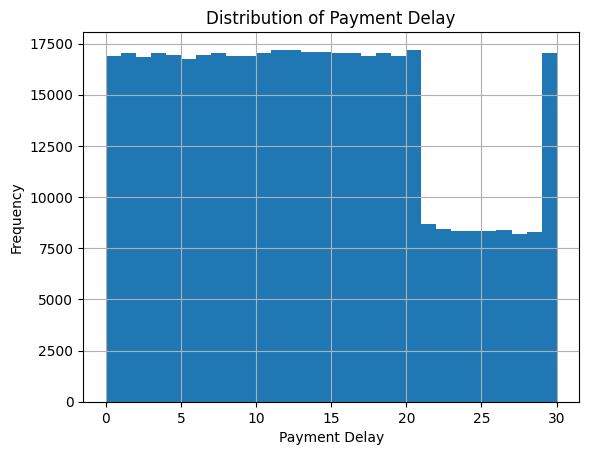

In [48]:
# What characteristics define customers who delay payments?
# Customers who churn exhibit both higher payment delays and significantly more support interactions. This suggests that financial difficulties and service-related issues may be interconnected, potentially contributing to customer dissatisfaction.

data["Payment Delay"].hist(bins=30)
plt.title("Distribution of Payment Delay")
plt.xlabel("Payment Delay")
plt.ylabel("Frequency")
plt.show()

In [49]:
high = data["Payment Delay"].quantile(0.75)
low = data["Payment Delay"].quantile(0.25)
data["Payment_Delay_Category"] = data["Payment Delay"].apply(lambda x: 'High Delay' if x >= high else ('Low Delay' if x <= low else 'Moderate Delay'))
data["Payment_Delay_Category"].value_counts()

Payment_Delay_Category
Moderate Delay    204327
Low Delay         118408
High Delay        118097
Name: count, dtype: int64

In [50]:
data.groupby("Payment_Delay_Category")[["Total Spend", "Support Calls", "Payment Delay","Usage Frequency", "Churn"]].mean().reset_index()

,Payment_Delay_Category,Total Spend,Support Calls,Payment Delay,Usage Frequency,Churn
0,High Delay,579.525517,4.503281,23.764829,15.586763,0.845161
1,Low Delay,651.095861,3.272296,2.997568,15.896502,0.464817
2,Moderate Delay,650.435131,3.277398,12.500619,15.883491,0.465675


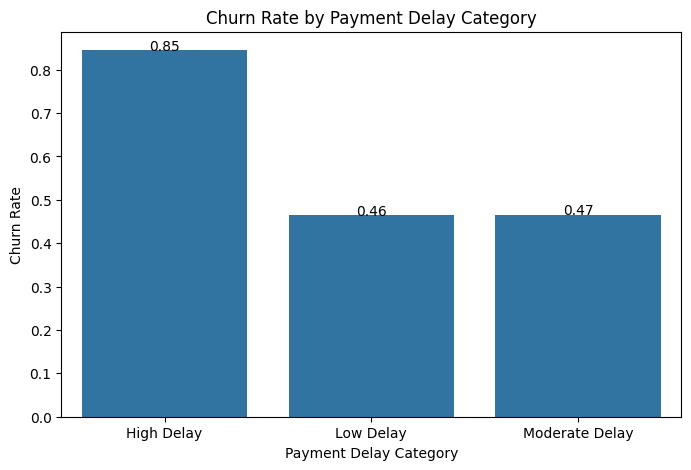

In [51]:
churn_delay = data.groupby("Payment_Delay_Category")["Churn"].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=churn_delay, x="Payment_Delay_Category", y="Churn")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center')

plt.title("Churn Rate by Payment Delay Category")
plt.ylabel("Churn Rate")
plt.xlabel("Payment Delay Category")

plt.show()

In [52]:
# - Are high-value customers more or less likely to delay payments?
# - Is there a relationship between payment delay and usage frequency?

data_grouped = data.groupby(["Customer_Value", "Churn_status"])[["Payment Delay", "Usage Frequency"]].mean().reset_index()


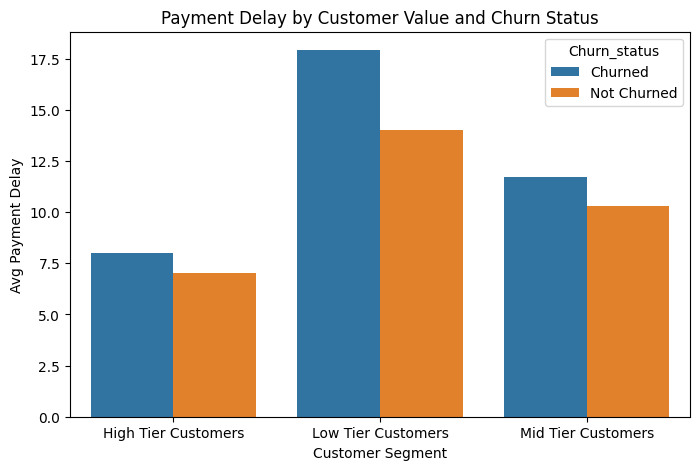

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=data_grouped,  # your grouped dataframe
    x="Customer_Value",
    y="Payment Delay",
    hue="Churn_status"
)

plt.title("Payment Delay by Customer Value and Churn Status")
plt.ylabel("Avg Payment Delay")
plt.xlabel("Customer Segment")

plt.show()

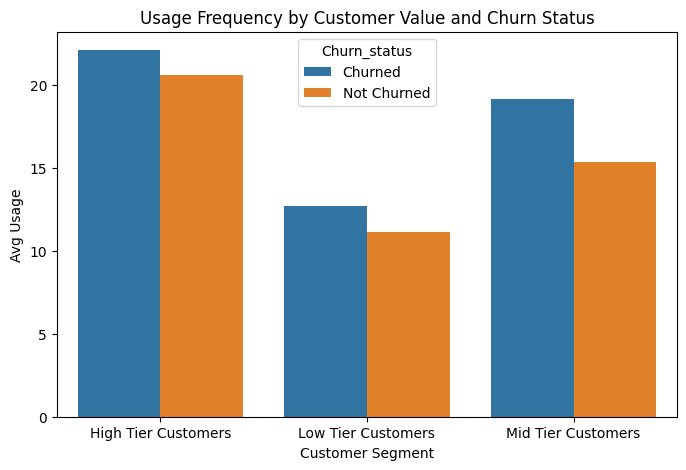

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=data_grouped,
    x="Customer_Value",
    y="Usage Frequency",
    hue="Churn_status"
)

plt.title("Usage Frequency by Customer Value and Churn Status")
plt.ylabel("Avg Usage")
plt.xlabel("Customer Segment")

plt.show()

In [55]:
melted = data_grouped.melt(
    id_vars=["Customer_Value", "Churn_status"],
    value_vars=["Payment Delay", "Usage Frequency"],
    var_name="Metric",
    value_name="Value"
)

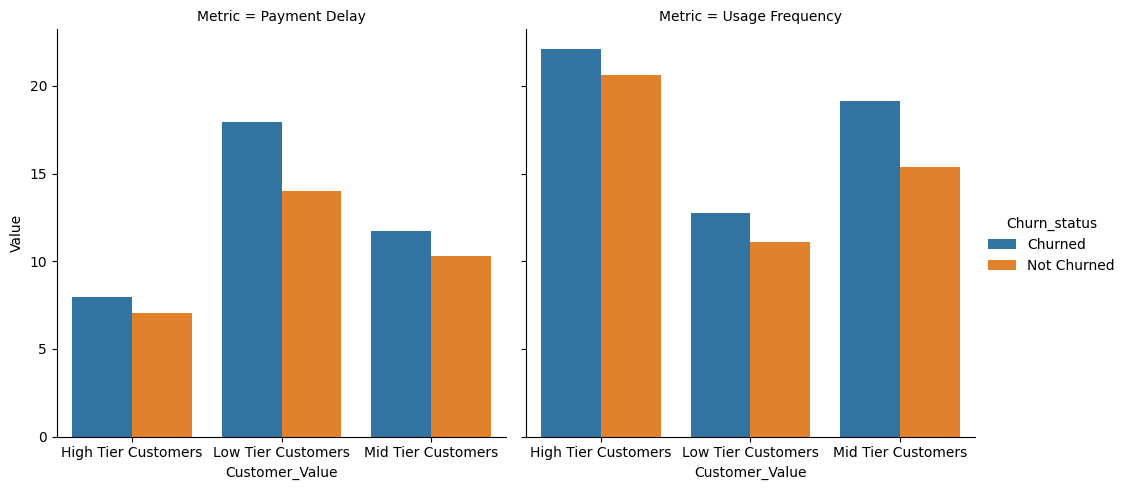

In [56]:
sns.catplot(
    data=melted,
    x="Customer_Value",
    y="Value",
    hue="Churn_status",
    col="Metric",
    kind="bar"
)

#### 📞 Support & Experience
- Which customers require the most support?
- Do customers with high support calls have lower engagement or spending?
- Is there a pattern between support usage and tenure?
- Are new customers more likely to contact support?

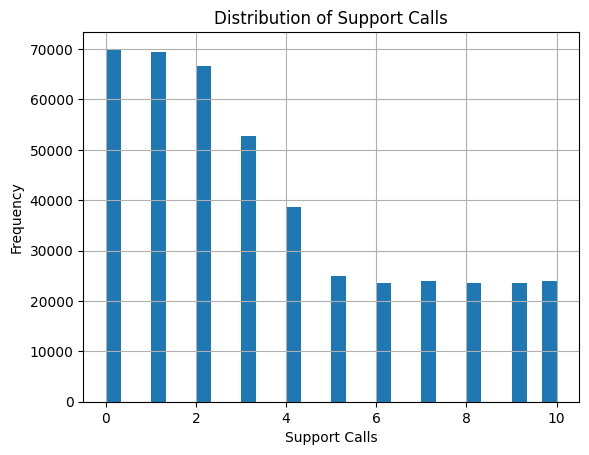

In [57]:
# Which customers require the most support?
# To answer this question, we can analyze the average number of support calls by customer value and churn status. We can also visualize this relationship using a bar plot to see if there are specific customer segments that require more support interactions, which may indicate underlying issues or dissatisfaction.

data["Support Calls"].hist(bins=30)
plt.title("Distribution of Support Calls")
plt.xlabel("Support Calls")
plt.ylabel("Frequency")
plt.show()

In [58]:
data["Support Calls"].describe()

count    440832.000000
mean          3.604437
std           3.070218
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max          10.000000
Name: Support Calls, dtype: float64

In [59]:
low_support = data["Support Calls"].quantile(0.25)
high_support = data["Support Calls"].quantile(0.75)
data["Support_Category"] = data["Support Calls"].apply(lambda x: 'High Support' if x >= high_support else ('Low Support' if x <= low_support else 'Moderate Support'))
data["Support_Category"].value_counts()

Support_Category
Moderate Support    182968
Low Support         139351
High Support        118513
Name: count, dtype: int64

In [60]:
# Do customers with high support calls have lower engagement or spending?
# To answer this question, we can analyze the average total spend and usage frequency by support category. We can also visualize this relationship using bar plots to see if customers with high support calls tend to have lower engagement or spending compared to those with low support calls.
data.groupby("Support_Category")[["Total Spend", "Usage Frequency", "Churn"]].mean().reset_index()

,Support_Category,Total Spend,Usage Frequency,Churn
0,High Support,550.130574,15.516019,1.000000
1,Low Support,680.994438,15.995960,0.303227
2,Moderate Support,646.789395,15.852750,0.487686


In [61]:
data.groupby("Support_Category")[["Total Spend", "Usage Frequency","Payment Delay", "Churn"]].mean().reset_index()

,Support_Category,Total Spend,Usage Frequency,Payment Delay,Churn
0,High Support,550.130574,15.516019,15.007366,1.000000
1,Low Support,680.994438,15.995960,11.736155,0.303227
2,Moderate Support,646.789395,15.852750,12.579752,0.487686


Customers with higher support interactions exhibit significantly higher churn rates and lower total spend, indicating that frequent service issues are strongly associated with customer dissatisfaction and reduced value.

However, usage frequency remains relatively stable across support levels, suggesting that support interactions do not significantly impact engagement, but are more closely linked to service-related challenges and customer attrition.

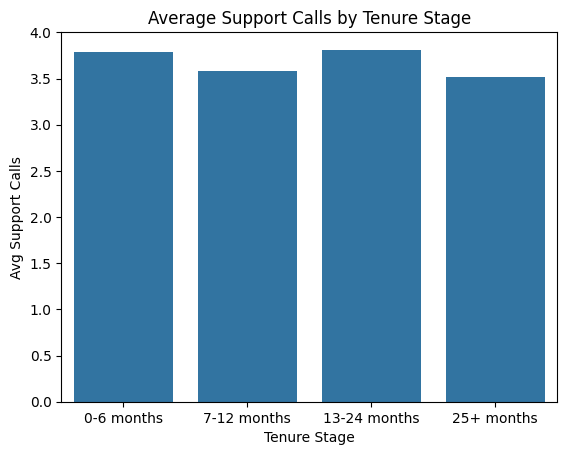

In [62]:
# Is there a pattern between support usage and tenure?
# To answer this question, we can analyze the average number of support calls by tenure stage. We can also visualize this relationship using a bar plot to see if there is a pattern between support usage and tenure, such as whether customers with longer tenure tend to require more or less support compared to newer customers.
support_tenure = data.groupby("Tenure_Stage")["Support Calls"].mean().reset_index()

sns.barplot(
    data=support_tenure,
    x="Tenure_Stage",
    y="Support Calls"
)

plt.title("Average Support Calls by Tenure Stage")
plt.ylabel("Avg Support Calls")
plt.xlabel("Tenure Stage")

plt.show()

Support interactions do not show a significant relationship with customer tenure. The average number of support calls remains relatively stable across all tenure stages, suggesting that support usage is driven by customer-specific issues rather than lifecycle stage.

### 📦 Subscription & Plan Insights
- Which subscription types attract high-value customers?
- How does customer behavior vary across different plans?
- Do longer contracts influence usage or spending patterns?

In [ ]:
# Which subscription types attract high-value customers?
# To answer this question, we can analyze the average total spend and usage frequency by subscription type. We can also visualize this relationship using bar plots to see if certain subscription types are more likely to attract high-value customers compared to others.

data.groupby("Subscription Type")[["Total Spend", "Usage Frequency","Payment Delay", "Churn"]].mean().reset_index()

,Subscription Type,Total Spend,Usage Frequency,Payment Delay,Churn
0,Basic,628.673496,15.808678,13.026310,0.581782
1,Premium,632.926463,15.809293,12.916766,0.559417
2,Standard,633.132253,15.804564,12.956420,0.560700


Subscription type does not significantly impact churn or customer value — behavioral factors are more important”